In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('../data/processed/orders_clean.csv', 
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

order_items = pd.read_csv('../data/processed/order_items_clean.csv',
                          parse_dates=['shipping_limit_date'])

customers = pd.read_csv('../data/processed/customers_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
payments = pd.read_csv('../data/processed/payments_clean.csv')
reviews = pd.read_csv('../data/processed/reviews_clean.csv')
geolocation = pd.read_csv('../data/processed/geolocation_clean.csv')
translation = pd.read_csv('../data/processed/translation_clean.csv')

print("All datasets loaded from processed folder")

All datasets loaded from processed folder


In [3]:
df = customers[['customer_unique_id', 'customer_id']].copy()
print(df.shape)
display(df.head(5))

(99441, 2)


,customer_unique_id,customer_id
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7
1,290c77bc529b7ac935b93aa66c333dc3,18955e83d337fd6b2def6b18a428ac77
2,060e732b5b29e8181a18229c7b0b2b5e,4e7b3e00288586ebd08712fdd0374a03
3,259dac757896d24d7702b9acbbff3f3c,b2b6027bc5c5109e529d4dc6358b12c3
4,345ecd01c38d18a9036ed96c73b8d066,4f2d8ab171c80ec8364f7c12e35b23ad


In [4]:
df = df.merge(orders[['customer_id', 'order_id', 'order_purchase_timestamp','order_status']], on='customer_id', how='left')
print(df.shape)
display(df.head(5))

(99441, 5)


,customer_unique_id,customer_id,order_id,order_purchase_timestamp,order_status
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,delivered
1,290c77bc529b7ac935b93aa66c333dc3,18955e83d337fd6b2def6b18a428ac77,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,delivered
2,060e732b5b29e8181a18229c7b0b2b5e,4e7b3e00288586ebd08712fdd0374a03,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,delivered
3,259dac757896d24d7702b9acbbff3f3c,b2b6027bc5c5109e529d4dc6358b12c3,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,delivered
4,345ecd01c38d18a9036ed96c73b8d066,4f2d8ab171c80ec8364f7c12e35b23ad,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,delivered


In [5]:
df = df[df['order_status'] == 'delivered'].copy()
print("After filtering only delivered orders, the shape of the dataset is: ", df.shape)
print("Unique order statuses in the filtered dataset:", df['order_status'].unique())

After filtering only delivered orders, the shape of the dataset is:  (96478, 5)
Unique order statuses in the filtered dataset: <StringArray>
['delivered']
Length: 1, dtype: str


In [6]:
df= df.merge(order_items[['order_id', 'price']], on='order_id', how='left')
print(df.shape)
display(df.head(5))

(110197, 6)


,customer_unique_id,customer_id,order_id,order_purchase_timestamp,order_status,price
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,delivered,124.99
1,290c77bc529b7ac935b93aa66c333dc3,18955e83d337fd6b2def6b18a428ac77,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,delivered,289.00
2,060e732b5b29e8181a18229c7b0b2b5e,4e7b3e00288586ebd08712fdd0374a03,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,delivered,139.94
3,259dac757896d24d7702b9acbbff3f3c,b2b6027bc5c5109e529d4dc6358b12c3,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,delivered,149.94
4,345ecd01c38d18a9036ed96c73b8d066,4f2d8ab171c80ec8364f7c12e35b23ad,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,delivered,230.00


In [7]:
df = df.drop(columns='customer_id')
print("Final Master Dataset created with shape: ", df.shape)
display(df.head(5))

Final Master Dataset created with shape:  (110197, 5)


,customer_unique_id,order_id,order_purchase_timestamp,order_status,price
0,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,delivered,124.99
1,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,delivered,289.00
2,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,delivered,139.94
3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,delivered,149.94
4,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,delivered,230.00


In [8]:
reference_date = pd.Timestamp('2018-10-01')

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

display(rfm.head())


,customer_unique_id,order_purchase_timestamp,order_id,price
0,0000366f3b9a7992bf8c76cfdf3221e2,143,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,146,1,18.90
2,0000f46a3911fa3c0805444483337064,569,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,353,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,320,1,180.00


In [9]:
rfm = rfm.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'price': 'monetary'
})
display(rfm.head())
rfm[['recency', 'frequency', 'monetary']].describe()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,143,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,146,1,18.90
2,0000f46a3911fa3c0805444483337064,569,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,353,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,320,1,180.00


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,269.478888,1.180370,141.621480
std,152.595050,0.620857,215.694014
min,32.000000,1.000000,0.850000
25%,146.000000,1.000000,47.650000
50%,250.000000,1.000000,89.730000
75%,378.000000,1.000000,154.737500
max,745.000000,24.000000,13440.000000


In [10]:
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, 
                           labels=[4, 3, 2, 1])

rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                           q=4, labels=[1, 2, 3, 4])

rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 
                           q=4, labels=[1, 2, 3, 4])

rfm['rfm_score'] = (rfm['r_score'].astype(int) + 
                    rfm['f_score'].astype(int) + 
                    rfm['m_score'].astype(int))

print(rfm[['recency', 'frequency', 'monetary', 
           'r_score', 'f_score', 'm_score', 'rfm_score']].head(10))

   recency  frequency  monetary r_score f_score m_score  rfm_score
0      143          1    129.90       4       1       3          8
1      146          1     18.90       4       1       1          6
2      569          1     69.00       1       1       2          4
3      353          1     25.99       2       1       1          4
4      320          1    180.00       2       1       4          7
5      178          1    154.00       3       1       3          7
6      163          1     27.99       3       1       1          5
7      214          2    382.00       3       4       4         11
8      575          1    135.00       1       1       3          5
9      202          1    104.90       3       1       3          7


### Why is Recency Scoring Inverted?

Recency measures the number of days since a customer's most recent purchase. A lower recency value means the customer purchased more recently, making them more engaged and more likely to respond to future marketing efforts. Therefore, customers with the smallest recency values receive the highest score (4), while customers who have not purchased for a long time receive the lowest score (1). This inversion ensures that higher RFM scores consistently represent more valuable customers across all three dimensions.

In [11]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    score = row['rfm_score']
    
    if r == 4 and f == 4 and m == 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r == 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalist'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r == 1 and f >= 3:
        return 'Lost Champion'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['segment'].value_counts())

segment
Loyal Customer        21238
Lost                  18645
At Risk               11813
New Customer          11697
Lost Champion         11481
Cannot Lose Them      10883
Potential Loyalist     5454
Champion               2147
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt

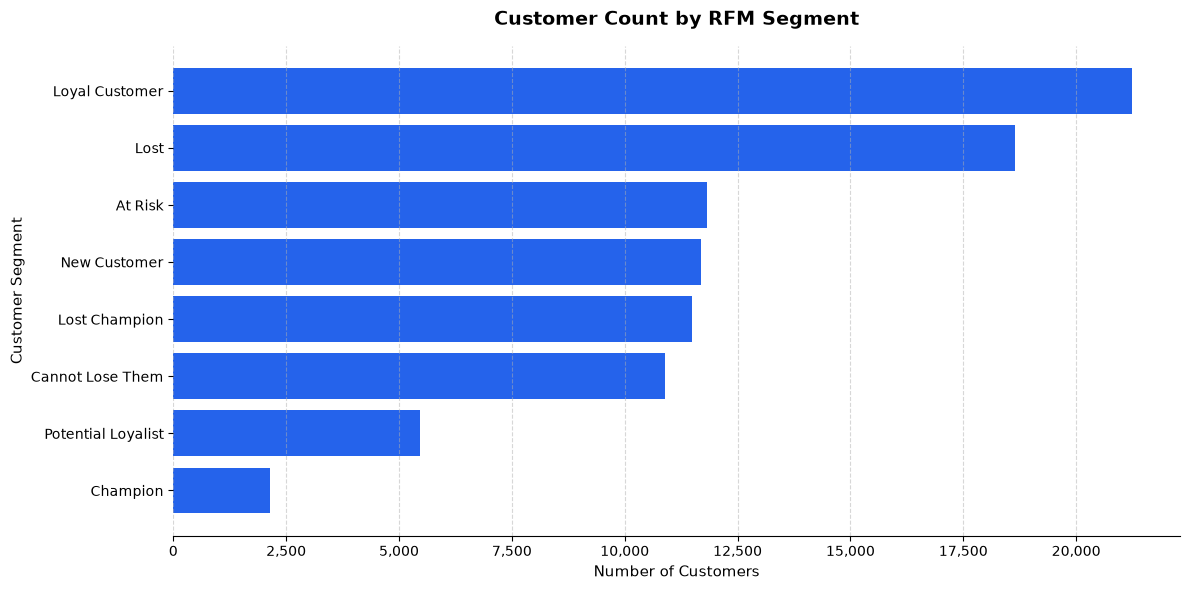

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Count customers in each segment
segment_counts = (rfm['segment']
                  .value_counts()
                  .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(segment_counts.index,
         segment_counts.values,
         color='#2563EB',
         edgecolor='none')

ax.set_title('Customer Count by RFM Segment',
             fontsize=14,
             fontweight='bold',
             pad=15)

ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_ylabel('Customer Segment', fontsize=11)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()

plt.savefig('../reports/rfm_segment_counts.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

In [14]:
segment_value = (rfm
                 .groupby('segment')['monetary']
                 .mean()
                 .sort_values(ascending=True)
                 .reset_index())

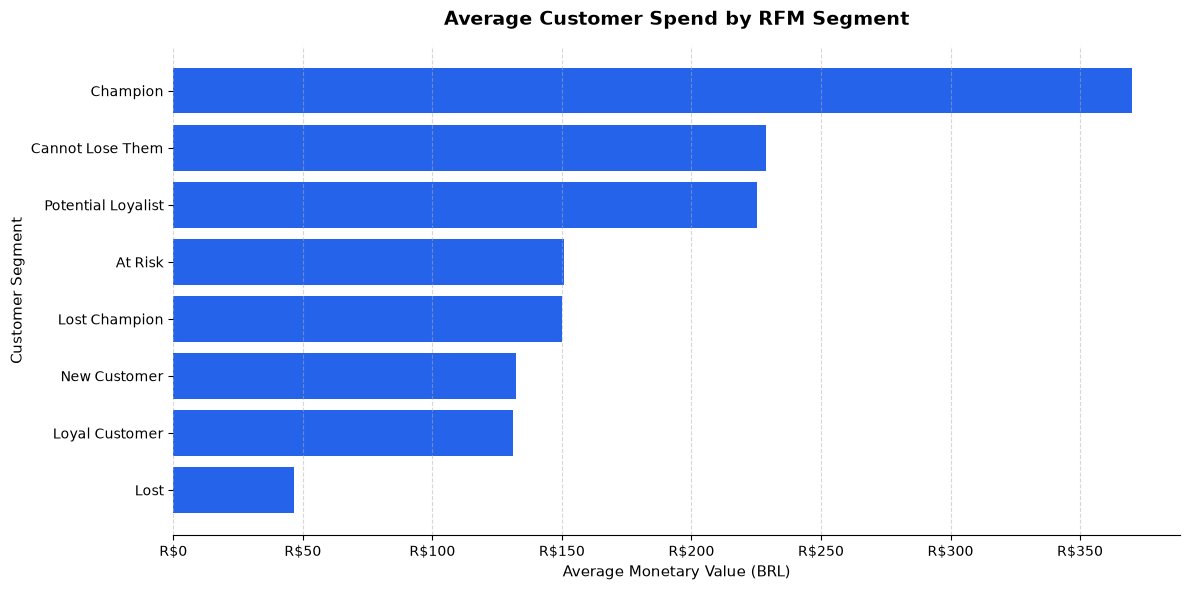

In [15]:
fig, ax = plt.subplots(figsize=(12,6))

ax.barh(segment_value['segment'],
         segment_value['monetary'],
         color='#2563EB',
         edgecolor='none')

ax.set_title('Average Customer Spend by RFM Segment',
             fontsize=14,
             fontweight='bold',
             pad=15)

ax.set_xlabel('Average Monetary Value (BRL)',
              fontsize=11)

ax.set_ylabel('Customer Segment',
              fontsize=11)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}')
)

ax.grid(axis='x',
        linestyle='--',
        alpha=0.5)

ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()

plt.savefig('../reports/rfm_average_monetary.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

### Business Interpretation

The average monetary value varies considerably across customer segments. While some segments contain a large number of customers, they contribute relatively little revenue per customer. High-value segments such as Champions and Cannot Lose Them generate significantly higher average spending, making them the highest priority for retention and personalized marketing campaigns.

# Executive Summary

**Prepared for:** Daniel, Head of Growth  
**Prepared by:** Noor Ul Saba  
**Date:** July 2026

The RFM analysis reveals that Olist's customer base is highly diverse in terms of purchasing behavior and value. While a small proportion of customers consistently purchase recently, frequently, and spend the most, a much larger portion consists of customers who have made only one or two purchases. This suggests that customer acquisition has been successful, but customer retention presents a significant opportunity for improvement.

**Champion** and **Loyal Customer** segments represent Olist's most valuable customers. These customers purchase frequently, have bought recently, and contribute a disproportionately high share of total revenue. They should receive priority treatment through loyalty programs, early access to promotions, exclusive offers, and personalized recommendations to maximize lifetime value and encourage continued engagement.

The **New Customer** and **Potential Loyalist** segments represent the strongest growth opportunity. These customers have purchased recently but have not yet developed consistent purchasing habits. Marketing efforts should focus on converting these customers into repeat buyers through welcome campaigns, personalized product recommendations, and targeted follow-up communications after their initial purchase.

The **At Risk**, **Cannot Lose Them**, **Lost Champion**, and **Lost** segments require different retention strategies. High-value customers who have become inactive should be targeted with personalized win-back campaigns, while lower-value inactive customers should receive cost-effective automated marketing. Customers who remain unresponsive after multiple engagement attempts should receive minimal marketing investment, allowing resources to be focused on higher-value customer segments with greater revenue potential.

Overall, the RFM segmentation provides a practical framework for allocating marketing resources efficiently. Rather than treating every customer identically, Olist can tailor communication, promotions, and retention strategies according to customer value and purchasing behavior. This customer-centric approach is expected to improve retention, increase customer lifetime value, and optimize marketing return on investment.